In [112]:
import pandas as pd

### DATA IMPORTING AND EXPLORATION

##### we have 5 csv files which we are going to import and explore

In [113]:
df_bookings = pd.read_csv("datasets/fact_bookings.csv")
print(df_bookings.shape)
df_bookings.head()

(134590, 12)


,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920


In [114]:
df_bookings['booking_status'].value_counts()

booking_status
Checked Out    94411
Cancelled      33420
No Show         6759
Name: count, dtype: int64

In [115]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


In [116]:
df_bookings['booking_platform'].value_counts()

booking_platform
others            55066
makeyourtrip      26898
logtrip           14756
direct online     13379
tripster           9630
journey            8106
direct offline     6755
Name: count, dtype: int64

In [117]:
df_bookings['room_category'].value_counts()

room_category
RT2    49505
RT1    38446
RT3    30566
RT4    16073
Name: count, dtype: int64

<Axes: ylabel='booking_platform'>

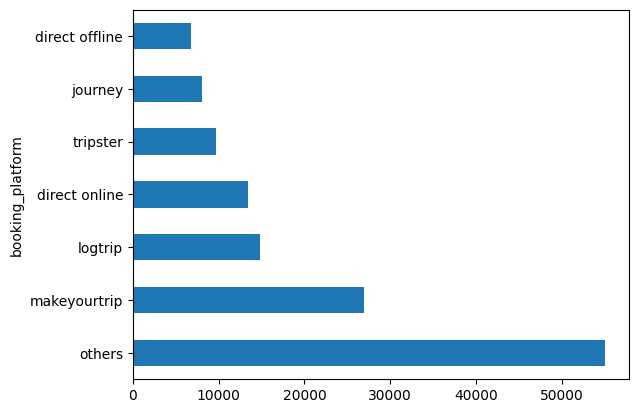

In [118]:
df_bookings['booking_platform'].value_counts().plot(kind='barh')

In [119]:
df_date = pd.read_csv('datasets/dim_date.csv')
df_hotels = pd.read_csv('datasets/dim_hotels.csv')
df_rooms = pd.read_csv('datasets/dim_rooms.csv')
df_agg_bookings = pd.read_csv('datasets/fact_aggregated_bookings.csv')

In [120]:
print(df_hotels.shape)
df_hotels.head()

(25, 4)


,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


In [121]:
df_hotels['category'].value_counts()

category
Luxury      16
Business     9
Name: count, dtype: int64

In [122]:
df_rooms.head()

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [123]:
df_rooms['room_class'].unique()

array(['Standard', 'Elite', 'Premium', 'Presidential'], dtype=object)

In [124]:
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
3,17558,1-May-22,RT1,30,19.0
4,16558,1-May-22,RT1,18,19.0


list of all property_ids

In [125]:
df_agg_bookings['property_id'].unique()

array([16559, 19562, 19563, 17558, 16558, 17560, 19558, 19560, 17561,
       16560, 16561, 16562, 16563, 17559, 17562, 17563, 18558, 18559,
       18561, 18562, 18563, 19559, 19561, 17564, 18560])

In [126]:
df_agg_bookings.groupby('property_id')['successful_bookings'].sum()

property_id
16558    3153
16559    7338
16560    4693
16561    4418
16562    4820
16563    7211
17558    5053
17559    6142
17560    6013
17561    5183
17562    3424
17563    6337
17564    3982
18558    4475
18559    5256
18560    6638
18561    6458
18562    7333
18563    4737
19558    4400
19559    4729
19560    6079
19561    5736
19562    5812
19563    5413
Name: successful_bookings, dtype: int64

No of successful bookings per property_id

<Axes: xlabel='property_id'>

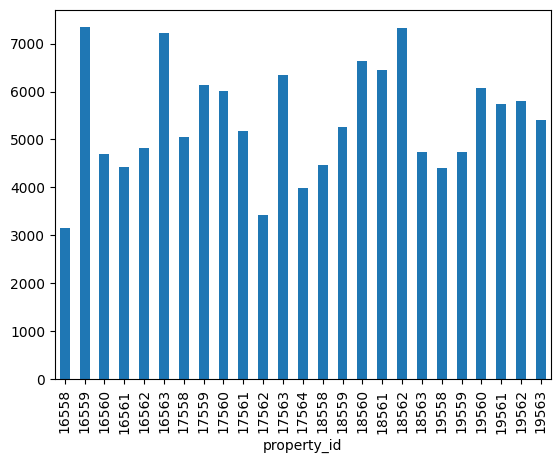

In [127]:
df_agg_bookings.groupby('property_id')['successful_bookings'].sum().plot(kind='bar')

Dates when bookings were higher than capacity

In [128]:
df_agg_bookings[df_agg_bookings['successful_bookings'] > df_agg_bookings['capacity']]

,property_id,check_in_date,room_category,successful_bookings,capacity
3,17558,1-May-22,RT1,30,19.0
12,16563,1-May-22,RT1,100,41.0
4136,19558,11-Jun-22,RT2,50,39.0
6209,19560,2-Jul-22,RT1,123,26.0
8522,19559,25-Jul-22,RT1,35,24.0
9194,18563,31-Jul-22,RT4,20,18.0


In [129]:
df_agg_bookings = df_agg_bookings[df_agg_bookings.successful_bookings<=df_agg_bookings.capacity]

the property which has max capacity

In [130]:
df_agg_bookings[df_agg_bookings['capacity'] == df_agg_bookings['capacity'].max()]['property_id'].unique()

array([17558])

### DATA CLEANING

In [131]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


In [132]:
df_bookings[df_bookings['no_guests']<=0]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
17924,May122218559RT44,18559,12/5/2022,12/5/2022,14-05-22,-10.0,RT4,direct online,NaN,No Show,20900,20900
18020,May122218561RT22,18561,8/5/2022,12/5/2022,14-05-22,-12.0,RT2,makeyourtrip,NaN,Cancelled,9000,3600
18119,May122218562RT311,18562,5/5/2022,12/5/2022,17-05-22,-6.0,RT3,direct offline,5.0,Checked Out,16800,16800
18121,May122218562RT313,18562,10/5/2022,12/5/2022,17-05-22,-4.0,RT3,direct online,NaN,Cancelled,14400,5760
56715,Jun082218562RT12,18562,5/6/2022,8/6/2022,13-06-22,-17.0,RT1,others,NaN,Checked Out,6500,6500
119765,Jul202219560RT220,19560,19-07-22,20-07-22,22-07-22,-1.0,RT2,others,NaN,Checked Out,13500,13500
134586,Jul312217564RT47,17564,30-07-22,31-07-22,1/8/2022,-4.0,RT4,logtrip,2.0,Checked Out,38760,38760


removing invalid guest no's

In [133]:
df_bookings = df_bookings[df_bookings['no_guests']>0]

removing outliers in revenue generated

In [134]:
df_bookings['revenue_generated'].min(), df_bookings['revenue_generated'].max()

(np.int64(6500), np.int64(28560000))

In [135]:
df_bookings['revenue_generated'].describe()

count    1.345780e+05
mean     1.537804e+04
std      9.304015e+04
min      6.500000e+03
25%      9.900000e+03
50%      1.350000e+04
75%      1.800000e+04
max      2.856000e+07
Name: revenue_generated, dtype: float64

In [136]:
revenue_generated_avg, revenue_generated_std = df_bookings['revenue_generated'].mean(),df_bookings['revenue_generated'].std()
revenue_generated_avg, revenue_generated_std

(np.float64(15378.036937686695), np.float64(93040.1549314641))

In [137]:
upper_limit = revenue_generated_avg + 3 * revenue_generated_std
lower_limit = revenue_generated_avg - 3 * revenue_generated_std
upper_limit, lower_limit

(np.float64(294498.50173207896), np.float64(-263742.4278567056))

checking if there is any revenue value less than 0 or greater than upper limit

In [138]:
df_bookings[df_bookings['revenue_generated'] < 0]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized


In [139]:
df_bookings[df_bookings['revenue_generated'] > upper_limit]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
111,May012216559RT32,16559,29-04-22,1/5/2022,2/5/2022,6.0,RT3,direct online,NaN,Checked Out,28560000,28560
315,May012216562RT22,16562,28-04-22,1/5/2022,4/5/2022,2.0,RT2,direct offline,3.0,Checked Out,12600000,12600
562,May012217559RT118,17559,26-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,2000000,4420
129176,Jul282216562RT26,16562,21-07-22,28-07-22,29-07-22,2.0,RT2,direct online,3.0,Checked Out,10000000,12600


In [140]:
df_bookings = df_bookings[df_bookings['revenue_generated'] <= upper_limit]

In [141]:
df_bookings['revenue_realized'].describe()

count    134573.000000
mean      12695.983585
std        6927.791692
min        2600.000000
25%        7600.000000
50%       11700.000000
75%       15300.000000
max       45220.000000
Name: revenue_realized, dtype: float64

In [142]:
revenue_realized_avg, revenue_realized_std = df_bookings['revenue_realized'].mean(),df_bookings['revenue_realized'].std()
revenue_realized_avg, revenue_realized_std

(np.float64(12695.983585117372), np.float64(6927.791692242814))

In [143]:
upper_limit = revenue_realized_avg + 3*revenue_realized_std
lower_limit = revenue_realized_avg - 3*revenue_realized_std
upper_limit, lower_limit

(np.float64(33479.358661845814), np.float64(-8087.391491611072))

In [144]:
df_bookings[df_bookings['revenue_realized'] > upper_limit]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
137,May012216559RT41,16559,27-04-22,1/5/2022,7/5/2022,4.0,RT4,others,NaN,Checked Out,38760,38760
139,May012216559RT43,16559,1/5/2022,1/5/2022,2/5/2022,6.0,RT4,tripster,3.0,Checked Out,45220,45220
143,May012216559RT47,16559,28-04-22,1/5/2022,3/5/2022,3.0,RT4,others,5.0,Checked Out,35530,35530
149,May012216559RT413,16559,24-04-22,1/5/2022,7/5/2022,5.0,RT4,logtrip,NaN,Checked Out,41990,41990
222,May012216560RT45,16560,30-04-22,1/5/2022,3/5/2022,5.0,RT4,others,3.0,Checked Out,34580,34580
...,...,...,...,...,...,...,...,...,...,...,...,...
134328,Jul312219560RT49,19560,31-07-22,31-07-22,2/8/2022,6.0,RT4,direct online,5.0,Checked Out,39900,39900
134331,Jul312219560RT412,19560,31-07-22,31-07-22,1/8/2022,6.0,RT4,others,2.0,Checked Out,39900,39900
134467,Jul312219562RT45,19562,28-07-22,31-07-22,1/8/2022,6.0,RT4,makeyourtrip,4.0,Checked Out,39900,39900
134474,Jul312219562RT412,19562,25-07-22,31-07-22,6/8/2022,5.0,RT4,direct offline,5.0,Checked Out,37050,37050


we can see that all bookings which has revenue realized higher than the upper limit belongs to 
RT4 which is Presidential suite where rent can be higher, so lets make a seperate analysis for RT4 rooms

In [145]:
df_bookings[df_bookings['room_category'] == 'RT4'].describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,16071.000000,16071.000000,6879.000000,16071.000000,16071.000000
mean,18031.070437,2.105283,3.687164,27465.457034,23439.308444
std,1034.119639,1.207111,1.266633,6310.403418,9048.599076
min,16558.000000,1.000000,1.000000,19000.000000,7600.000000
25%,17559.000000,1.000000,3.000000,19000.000000,19000.000000
50%,18558.000000,2.000000,4.000000,28500.000000,26600.000000
75%,18562.000000,2.000000,5.000000,32300.000000,32300.000000
max,19563.000000,6.000000,5.000000,45220.000000,45220.000000


In [146]:
rt4_avg, rt4_std = df_bookings[df_bookings['room_category'] == 'RT4']['revenue_realized'].mean(), df_bookings[df_bookings['room_category'] == 'RT4']['revenue_realized'].std()

In [147]:
rt4_avg, rt4_std

(np.float64(23439.308443780723), np.float64(9048.599075739918))

In [148]:
upper_limit = rt4_avg + 3*rt4_std
upper_limit

np.float64(50585.10567100048)

the upper limit for rt4 rooms is 50585 and in the dataframe the max value is 45220 so we can Say 
that there are no outliers

In [149]:
df_bookings.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77897
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

We can see that the ratings column has 77897 null values but because there are too many values
and also with domain understanding of ratings we chose not to replace null values

In [150]:
df_agg_bookings.isnull().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               0
dtype: int64

### DATA TRANSFORMATION

now we will be creating occupancy pct columns

In [151]:
df_agg_bookings['occ_pct'] = df_agg_bookings['successful_bookings']/df_agg_bookings['capacity']

In [152]:
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,0.833333
1,19562,1-May-22,RT1,28,30.0,0.933333
2,19563,1-May-22,RT1,23,30.0,0.766667
4,16558,1-May-22,RT1,18,19.0,0.947368
5,17560,1-May-22,RT1,28,40.0,0.700000


In [153]:
df_agg_bookings['occ_pct'] = df_agg_bookings['occ_pct'].apply(lambda x : round(x*100, 2))
df_agg_bookings.sample(5)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
7696,18563,16-Jul-22,RT4,13,18.0,72.22
8860,19558,28-Jul-22,RT3,7,21.0,33.33
7751,19562,17-Jul-22,RT3,20,29.0,68.97
4429,16562,14-Jun-22,RT2,21,43.0,48.84
4649,19563,16-Jun-22,RT2,26,45.0,57.78


### INSIGHTS

1. what is the average occupancy rate in each of the room categories?

In [154]:
df_agg_bookings.head(2)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,83.33
1,19562,1-May-22,RT1,28,30.0,93.33


In [155]:
df_rooms.head(2)

,room_id,room_class
0,RT1,Standard
1,RT2,Elite


In [156]:
df = pd.merge(df_agg_bookings, df_rooms, left_on='room_category', right_on='room_id')
df.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_id,room_class
0,16559,1-May-22,RT1,25,30.0,83.33,RT1,Standard
1,19562,1-May-22,RT1,28,30.0,93.33,RT1,Standard
2,19563,1-May-22,RT1,23,30.0,76.67,RT1,Standard
3,16558,1-May-22,RT1,18,19.0,94.74,RT1,Standard
4,17560,1-May-22,RT1,28,40.0,70.00,RT1,Standard


In [157]:
df.drop('room_category', axis = 1, inplace=True)

In [158]:
df.groupby('room_class')['occ_pct'].mean()

room_class
Elite           58.009756
Premium         58.028213
Presidential    59.277925
Standard        57.880828
Name: occ_pct, dtype: float64

INSIGHT-- Occupancy is fairly the same across room categories, suggesting that the difference is not strongly influencing customer choice.

2. What is the average occupancy rate per city?

In [159]:
df_hotels.head(3)

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi


In [160]:
df = pd.merge(df, df_hotels, on='property_id')
df.head(3)

,property_id,check_in_date,successful_bookings,capacity,occ_pct,room_id,room_class,property_name,category,city
0,16559,1-May-22,25,30.0,83.33,RT1,Standard,Atliq Exotica,Luxury,Mumbai
1,19562,1-May-22,28,30.0,93.33,RT1,Standard,Atliq Bay,Luxury,Bangalore
2,19563,1-May-22,23,30.0,76.67,RT1,Standard,Atliq Palace,Business,Bangalore


In [161]:
df.groupby('city')['occ_pct'].mean().sort_values(ascending=False)

city
Delhi        61.507341
Hyderabad    58.120652
Mumbai       57.902319
Bangalore    56.332376
Name: occ_pct, dtype: float64

INSIGHT-- Delhi achieves the highest occupancy but generates the lowest revenue, indicating that rooms may be priced lower or skewed toward lower-value bookings.

3. When was the occupancy better? Weekday or Weekend?

In [162]:
df_date.head(3)

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday


In [163]:
df = pd.merge(df, df_date, left_on='check_in_date', right_on='date')
df.head(3)

,property_id,check_in_date,successful_bookings,capacity,occ_pct,room_id,room_class,property_name,category,city,date,mmm yy,week no,day_type
0,19563,10-May-22,15,29.0,51.72,RT3,Premium,Atliq Palace,Business,Bangalore,10-May-22,May 22,W 20,weekeday
1,18560,10-May-22,19,30.0,63.33,RT1,Standard,Atliq City,Business,Hyderabad,10-May-22,May 22,W 20,weekeday
2,19562,10-May-22,18,30.0,60.00,RT1,Standard,Atliq Bay,Luxury,Bangalore,10-May-22,May 22,W 20,weekeday


In [164]:
df.drop('date', axis=1, inplace=True)

In [165]:
df.groupby('day_type')['occ_pct'].mean()

day_type
weekeday    50.883140
weekend     72.343625
Name: occ_pct, dtype: float64

INSIGHT-- There is a significant spike in occupancy during weekends, indicating strong leisure demand but underutilization during weekdays.

4. In the month of July what is average occpuancy for different cities?

In [166]:
df['mmm yy'].unique()

array(['May 22', 'Jun 22', 'Jul 22'], dtype=object)

In [167]:
df[df["mmm yy"] == 'Jul 22'].groupby('city')['occ_pct'].mean().sort_values(ascending=False)

city
Delhi        59.177886
Hyderabad    55.252163
Mumbai       55.235469
Bangalore    53.899829
Name: occ_pct, dtype: float64

INSIGHT-- In July, Delhi maintains the highest occupancy among all cities, while Bangalore continues to have the lowest. The relatively close occupancy values across cities suggest moderate demand overall, but consistent underperformance in Bangalore indicates location-specific or service-related issues.

<Axes: ylabel='city'>

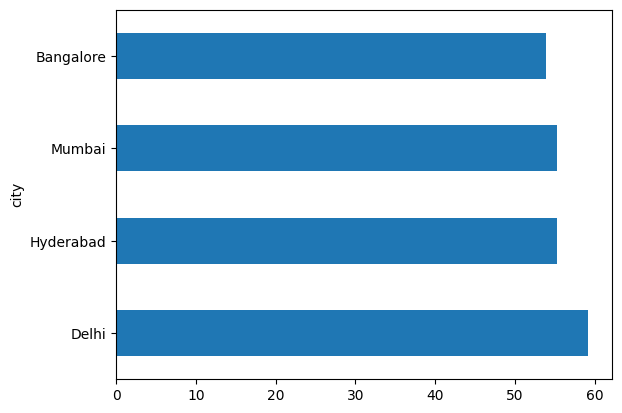

In [168]:
df[df["mmm yy"] == 'Jul 22'].groupby('city')['occ_pct'].mean().sort_values(ascending=False).plot(kind='barh')

5. We got new data for the month of august. Append that to existing data

In [169]:
df_aug = pd.read_csv('datasets/new_data_august.csv')
df_aug.head(3)

,property_id,property_name,category,city,room_category,room_class,check_in_date,mmm yy,week no,day_type,successful_bookings,capacity,occ%
0,16559,Atliq Exotica,Luxury,Mumbai,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,30,100.00
1,19562,Atliq Bay,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,21,30,70.00
2,19563,Atliq Palace,Business,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,23,30,76.67


In [170]:
print(df.shape)
df.columns

(6497, 13)


Index(['property_id', 'check_in_date', 'successful_bookings', 'capacity',
       'occ_pct', 'room_id', 'room_class', 'property_name', 'category', 'city',
       'mmm yy', 'week no', 'day_type'],
      dtype='object')

In [171]:
print(df_aug.shape)
df_aug.columns

(7, 13)


Index(['property_id', 'property_name', 'category', 'city', 'room_category',
       'room_class', 'check_in_date', 'mmm yy', 'week no', 'day_type',
       'successful_bookings', 'capacity', 'occ%'],
      dtype='object')

to combine aug data into the main dataset we have make the columns same in both the datasets

In [172]:
df_aug['occ_pct'] = df_aug['occ%']
df_aug.drop('occ%', axis = 1, inplace=True)
df_aug.head()

,property_id,property_name,category,city,room_category,room_class,check_in_date,mmm yy,week no,day_type,successful_bookings,capacity,occ_pct
0,16559,Atliq Exotica,Luxury,Mumbai,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,30,100.00
1,19562,Atliq Bay,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,21,30,70.00
2,19563,Atliq Palace,Business,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,23,30,76.67
3,19558,Atliq Grands,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,40,75.00
4,19560,Atliq City,Business,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,20,26,76.92


In [173]:
df_aug['room_id'] = df_aug['room_category']
df_aug.drop('room_category', axis = 1, inplace=True)

In [174]:
df = pd.concat([df, df_aug], ignore_index=True, axis=0)
df.head()

,property_id,check_in_date,successful_bookings,capacity,occ_pct,room_id,room_class,property_name,category,city,mmm yy,week no,day_type
0,19563,10-May-22,15,29.0,51.72,RT3,Premium,Atliq Palace,Business,Bangalore,May 22,W 20,weekeday
1,18560,10-May-22,19,30.0,63.33,RT1,Standard,Atliq City,Business,Hyderabad,May 22,W 20,weekeday
2,19562,10-May-22,18,30.0,60.00,RT1,Standard,Atliq Bay,Luxury,Bangalore,May 22,W 20,weekeday
3,19563,10-May-22,16,30.0,53.33,RT1,Standard,Atliq Palace,Business,Bangalore,May 22,W 20,weekeday
4,17558,10-May-22,11,19.0,57.89,RT1,Standard,Atliq Grands,Luxury,Mumbai,May 22,W 20,weekeday


In [175]:
df.shape

(6504, 13)

6. How much is revenue realized per city?

In [178]:
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
7,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100


In [179]:
df_hotels.head()

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


In [180]:
df_bookings_comb = pd.merge(df_bookings, df_hotels, on="property_id")
df_bookings_comb.head(3)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
1,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi
2,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi


In [181]:
df_bookings_comb.groupby("city")["revenue_realized"].sum()

city
Bangalore    420383550
Delhi        294404488
Hyderabad    325179310
Mumbai       668569251
Name: revenue_realized, dtype: int64

INSIGHT-- Mumbai is the highest revenue-generating city, likely due to stronger demand or higher pricing power. In contrast, Delhi generates the lowest revenue, indicating weaker demand or ineffective pricing strategies.

7. How much is the revenue of each month?

In [183]:
df_date.head()

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday


In [184]:
df_bookings_comb.head(3)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
1,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi
2,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi


In [185]:
df_bookings_comb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134573 entries, 0 to 134572
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   booking_id         134573 non-null  object 
 1   property_id        134573 non-null  int64  
 2   booking_date       134573 non-null  object 
 3   check_in_date      134573 non-null  object 
 4   checkout_date      134573 non-null  object 
 5   no_guests          134573 non-null  float64
 6   room_category      134573 non-null  object 
 7   booking_platform   134573 non-null  object 
 8   ratings_given      56676 non-null   float64
 9   booking_status     134573 non-null  object 
 10  revenue_generated  134573 non-null  int64  
 11  revenue_realized   134573 non-null  int64  
 12  property_name      134573 non-null  object 
 13  category           134573 non-null  object 
 14  city               134573 non-null  object 
dtypes: float64(2), int64(3), object(10)
memory usage: 1

In [186]:
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      92 non-null     object
 1   mmm yy    92 non-null     object
 2   week no   92 non-null     object
 3   day_type  92 non-null     object
dtypes: object(4)
memory usage: 3.0+ KB


In [187]:
df_date['date'] = pd.to_datetime(df_date['date'])
df_date.head(3)

C:\Users\Parth Gupta\AppData\Local\Temp\ipykernel_22884\248606528.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_date['date'] = pd.to_datetime(df_date['date'])


,date,mmm yy,week no,day_type
0,2022-05-01,May 22,W 19,weekend
1,2022-05-02,May 22,W 19,weekeday
2,2022-05-03,May 22,W 19,weekeday


In [190]:
df_bookings_comb["check_in_date"] = pd.to_datetime(
    df_bookings_comb["check_in_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)
df_bookings_comb.head(3)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,2022-05-01,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
1,May012216558RT15,16558,27-04-22,2022-05-01,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi
2,May012216558RT16,16558,1/5/2022,2022-05-01,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi


In [191]:
df_bookings_comb = pd.merge(df_bookings_comb, df_date, left_on="check_in_date", right_on="date")
df_bookings_comb.head(3)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city,date,mmm yy,week no,day_type
0,May012216558RT12,16558,30-04-22,2022-05-01,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend
1,May012216558RT15,16558,27-04-22,2022-05-01,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend
2,May012216558RT16,16558,1/5/2022,2022-05-01,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend


In [192]:
df_bookings_comb.groupby("mmm yy")["revenue_realized"].sum()

mmm yy
Jul 22    572843348
Jun 22    553925855
May 22    581767396
Name: revenue_realized, dtype: int64

INSIGHT-- Revenue shows a drop in but shows recovery in July, suggesting possible seasonality or temporary demand slowdown.

In [193]:
df.head(1)

,property_id,check_in_date,successful_bookings,capacity,occ_pct,room_id,room_class,property_name,category,city,mmm yy,week no,day_type
0,19563,10-May-22,15,29.0,51.72,RT3,Premium,Atliq Palace,Business,Bangalore,May 22,W 20,weekeday


8. How much is revenue realized per hotel type?

In [194]:
df_bookings_comb.groupby("property_name")["revenue_realized"].sum().round(2).sort_values()

property_name
Atliq Seasons     66086735
Atliq Grands     211462134
Atliq Bay        259996918
Atliq Blu        260851922
Atliq City       285798439
Atliq Palace     304081863
Atliq Exotica    320258588
Name: revenue_realized, dtype: int64

INSIGHT-- Certain properties significantly outperform others, suggesting differences in location, pricing, or service quality.

9. What is average rating per city?

In [196]:
df_bookings_comb.groupby("city")["ratings_given"].mean().round(2)

city
Bangalore    3.41
Delhi        3.78
Hyderabad    3.66
Mumbai       3.65
Name: ratings_given, dtype: float64

INSIGHT-- Bangalore shows both the lowest occupancy and lowest customer ratings, indicating potential service or experience issues affecting demand.

10. a pie chart of revenue realized per booking platform

<Axes: ylabel='revenue_realized'>

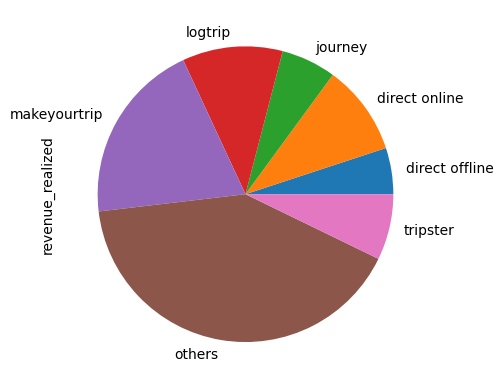

In [197]:
df_bookings_comb.groupby("booking_platform")["revenue_realized"].sum().plot(kind="pie")

INSIGHT-- A large portion of revenue comes from aggregated or unidentified platforms (“Others”), making it difficult for us to optimize platform strategy. Direct offline channels contribute the least.

The decline in business at Atliq Grands is not due to lack of demand overall, but due to uneven performance across cities, pricing inefficiencies, and underutilization during weekdays. While some cities like Delhi have strong demand, they fail to convert it into high revenue, whereas cities like Bangalore suffer from both low demand and poor customer satisfaction.

### RECOMMENDATIONS

1. Increase room prices gradually in high-demand cities such as Delhi  
Use dynamic pricing during peak demand

2. Bangalore shows low occupancy + low ratings


   Investigate service quality issues  
   Improve customer experience  
   Offer targeted discounts to boost demand  

3. Introduce weekday offers since weekdays occpancy is lower than weekends   
   Target corporate/business travelers

4. Break down and analyze “Others” platforms  
   Focus on platforms with high revenue realization  
   Promote direct bookings (website/app) to reduce commission  

5. Upsell premium room categories since some cities have good occupancy but not proportional revenue

6. Analyze top-performing properties (e.g., Atliq Exotica)  
   Apply best practices to low-performing hotels

7. Since revenue dipped in June and recovered in July, we can run promotions during low-demand months

The decline in business at Atliq Grands appears to be driven by multiple factors:

- Uneven occupancy across cities, with some locations underutilizing capacity  
- Pricing inefficiencies, particularly in high-demand cities like Delhi  
- Low customer ratings in cities like Bangalore affecting demand  
- Heavy reliance on certain booking platforms without clear performance insights  
- Significant drop in weekday occupancy leading to revenue loss 